In [2]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import signal
import heyoka as hy
from celmech import Poincare, PoincareHamiltonian
import symengine as se
import time
import sympy as sp

In [3]:
#constants and helper functions
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

In [4]:
#heyoka integration

def hk_integrate(pham,sim_time,num_data_points):
    #H_num = pham.H.subs(dict(pham.H_params))
    H_se = se.sympify(pham.H)
    clean_params_se = {se.sympify(k): v for k, v in dict(pham.H_params).items()
                   if not (hasattr(v, '__float__') and np.isnan(float(v)))}
    H_num = H_se.subs(clean_params_se)
    nan_symbols = {s: 0 for s in H_num.free_symbols 
               if str(s) not in {'Lambda1', 'Lambda2', 'eta1', 'eta2', 
                                  'kappa1', 'kappa2', 'lambda1', 'lambda2',
                                  'rho1', 'rho2', 'sigma1', 'sigma2'}}
    H_num = H_num.subs(nan_symbols)

    
    rho1,rho2,sigma1,sigma2 = se.symbols('rho1 rho2 sigma1 sigma2')
    sym_map = {s: 0 for s in H_num.free_symbols if str(s) in ('rho1', 'rho2', 'sigma1', 'sigma2')}
    H_planar = H_num.subs(sym_map)
    #H_planar = H_num.subs({rho1: 0, rho2: 0, sigma1: 0, sigma2: 0})
    H_planar = se.sympify(H_planar)
    print(sorted(str(s) for s in H_planar.free_symbols))

    lam1,lam2 = se.symbols('lambda1 lambda2')
    Lam1,Lam2 = se.symbols('Lambda1 Lambda2')
    eta1,eta2 = se.symbols('eta1 eta2')
    kap1, kap2 = se.symbols('kappa1 kappa2')

    print('*** Differentiating  ***')

    sym_dict = {str(s): s for s in H_planar.free_symbols}
    lam1 = sym_dict['lambda1']
    lam2 = sym_dict['lambda2']
    Lam1 = sym_dict['Lambda1']
    Lam2 = sym_dict['Lambda2']
    eta1 = sym_dict['eta1']
    eta2 = sym_dict['eta2']
    kap1 = sym_dict['kappa1']
    kap2 = sym_dict['kappa2']

    dLam1_dt = -se.diff(H_planar, lam1)
    dLam2_dt = -se.diff(H_planar, lam2)
    dlam1_dt =  se.diff(H_planar, Lam1)
    dlam2_dt =  se.diff(H_planar, Lam2)

    deta1_dt  = se.diff(H_planar, kap1)
    dkap1_dt  =  -se.diff(H_planar, eta1)
    deta2_dt  = se.diff(H_planar, kap2)
    dkap2_dt  =  -se.diff(H_planar, eta2)

    derivs = [dlam1_dt, dLam1_dt, dlam2_dt, dLam2_dt, deta1_dt, dkap1_dt, deta2_dt, dkap2_dt]

    vars_list = [lam1, Lam1, lam2, Lam2, eta1, kap1, eta2, kap2]
    func = se.Lambdify(vars_list,H_planar)

    jup = pham.state.particles[1]
    sat = pham.state.particles[2]

    initial_conditions = [jup.l, jup.Lambda, sat.l, sat.Lambda,jup.eta, jup.kappa, sat.eta, sat.kappa]
    derivs_at_0 = func(*initial_conditions)

    lam1_hy, Lam1_hy, lam2_hy, Lam2_hy, eta1_hy, kap1_hy, eta2_hy, kap2_hy = hy.make_vars('lam1_hy', 'Lam1_hy', 'lam2_hy', 'Lam2_hy', 'eta1_hy', 'kap1_hy', 'eta2_hy', 'kap2_hy')

    eqs_hy = [hy.from_sympy(sp.sympify(eq), {sp.Symbol('lambda1'): lam1_hy, 
                                          sp.Symbol('Lambda1'): Lam1_hy,
                                          sp.Symbol('lambda2'): lam2_hy, 
                                          sp.Symbol('Lambda2'): Lam2_hy,
                                          sp.Symbol('eta1'): eta1_hy, 
                                          sp.Symbol('kappa1'): kap1_hy,
                                          sp.Symbol('eta2'): eta2_hy, 
                                          sp.Symbol('kappa2'): kap2_hy})
           for eq in derivs]

    ta = hy.taylor_adaptive(sys=[(lam1_hy, eqs_hy[0]),(Lam1_hy, eqs_hy[1]),(lam2_hy, eqs_hy[2]),(Lam2_hy, eqs_hy[3]),(eta1_hy,  eqs_hy[4]),(kap1_hy,  eqs_hy[5]),(eta2_hy,  eqs_hy[6]),(kap2_hy,  eqs_hy[7])],
    state=initial_conditions,
    high_accuracy= True,
    time=0.0,
    tol=1e-18)

    e_i = float(func(*ta.state))
    print(e_i)

    times = np.linspace(0,sim_time,int(num_data_points))*2*np.pi
    e_sat = np.zeros(len(times))
    pomega_sat = np.zeros(len(times))

    start = time.perf_counter()
    print('*** Starting Simulation ***')
    for i in tqdm(range(len(times))):
        ta.propagate_until(times[i])
        L, eta, kap = ta.state[3], ta.state[6], ta.state[7]
        e_sat[i] = get_ecc(kap, eta, L)
        pomega_sat[i] = get_pomega(kap, eta)
        
    end = time.perf_counter()

    e_f = float(func(*ta.state))
    print(e_f)
    e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
    print(f'Energy Percent Change: {e_per} %')
    
    print('*** Simulation Complete ***')

    print('Time elapsed  = ' + str(end-start) + ' seconds')

    return times, pomega_sat, e_sat

Initial Energy: -8.880166071428572e-05
Initital Angular Momentum: <rebound.vectors.Vec3d object at 0x7f5ac9e44440, [0.0, 0.0, 0.002348194793041187]>


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:01<00:00, 5431.52it/s]


Final Energy: -8.88016607142837e-05
Energy Percent Change: 2.273973853654967e-12 %
Final Angular Momentum: <rebound.vectors.Vec3d object at 0x7f5ac5dfc190, [0.0, 0.0, 0.0023481947930412126]>
Megno Value: 2.5805535344698387


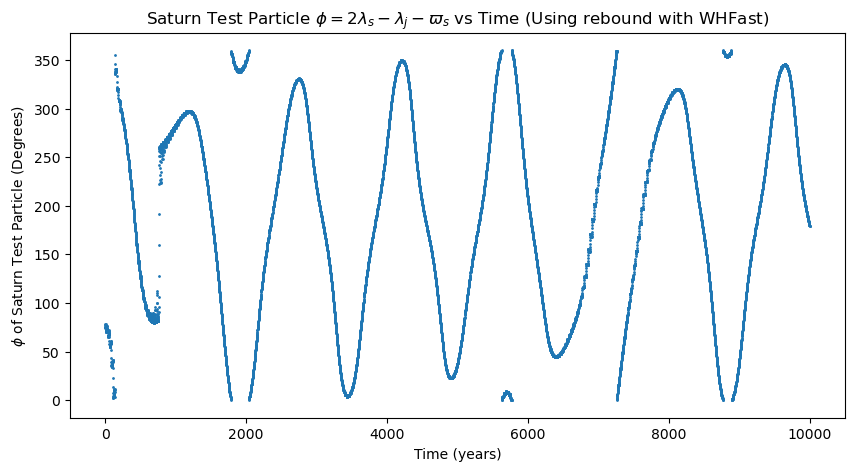

In [5]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=0,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e4,int(1e4))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
lambda_sat = np.zeros(len(times))
lambda_j = np.zeros(len(times))
e_j = np.zeros(len(times))
H_energy = np.zeros(len(times))

sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    lambda_sat[i] = sim.particles[2].l
    lambda_j[i] = sim.particles[1].l
    H_energy[i] = sim.energy()
    

e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Final Angular Momentum: ' + str(sim.angular_momentum()))
print('Megno Value: ' + str(sim.megno()))

phi = 2*lambda_sat - lambda_j - long_peri_sat

phi = np.degrees(phi)
phi = phi%360

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), phi,s=1)
plt.ylabel(r'$\phi$ of Saturn Test Particle (Degrees)')
plt.xlabel("Time (years)")
plt.title(r'Saturn Test Particle $\phi = 2\lambda_s - \lambda_j - \varpi_s$ vs Time (Using rebound with WHFast)')
plt.show()

Initial Energy: " -8.880166632927945e-05


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:04<00:00, 2470.24it/s]


Final Energy: " -8.880166632927967e-05
Energy Percent Change: 2.44185096361874e-13 %


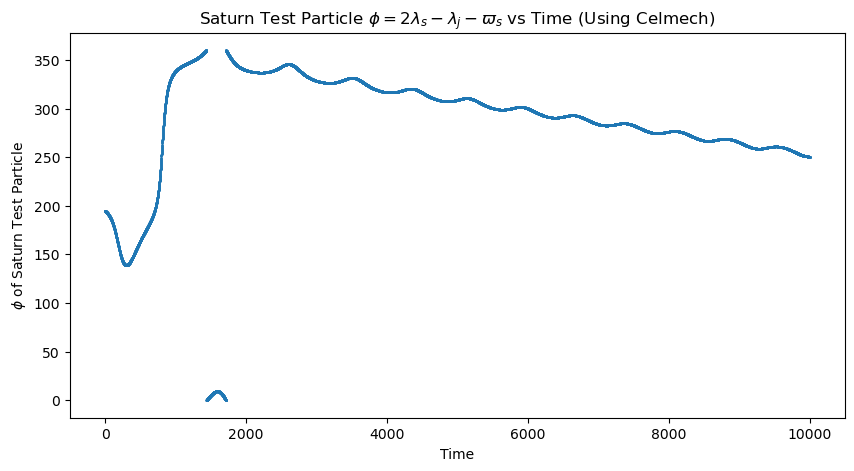

In [16]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e4,int(1e4))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
lambda_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))
lambda_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)

e_i = pham.calculate_energy()
print('Initial Energy: " '+ str(e_i))

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    long_peri_sat[i] = pham.state.particles[2].pomega
    e_sat[i] = pham.state.particles[2].e
    lambda_sat = pham.state.particles[2].l
    lambda_j = pham.state.particles[1].l

e_f = pham.calculate_energy()
print('Final Energy: " '+ str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')

phi = 2*lambda_sat - lambda_j - long_peri_sat

phi = np.degrees(phi)
phi = phi%360

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), phi,s=1)
plt.ylabel(r'$\phi$ of Saturn Test Particle')
plt.xlabel("Time")
plt.title(r'Saturn Test Particle $\phi = 2\lambda_s - \lambda_j - \varpi_s$ vs Time (Using Celmech)')
plt.show()

In [28]:
from scipy.integrate import solve_ivp
import numpy as np

def andoyer(t, y, epsilon, eta, nu):
    phi, delta = y
    dphi = delta
    ddelta = -epsilon * np.sin(phi) + eta * np.sin(phi - nu * t)
    return [dphi, ddelta]

epsilon = 0.01   
eta = 0.001      
nu = 0.05        

phi0 = np.pi        
delta0 = 0.01      

sol = solve_ivp(andoyer, [0, 1e5], [phi0, delta0], 
                args=(epsilon, eta, nu),
                method='DOP853', 
                rtol=1e-10, atol=1e-12,
                dense_output=True)

In [29]:
pvars = Poincare.from_Simulation(sim)
pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(2, 1, max_order=1)

Text(0.5, 1.0, 'Poincaré Section — Andoyer + Perturbation')

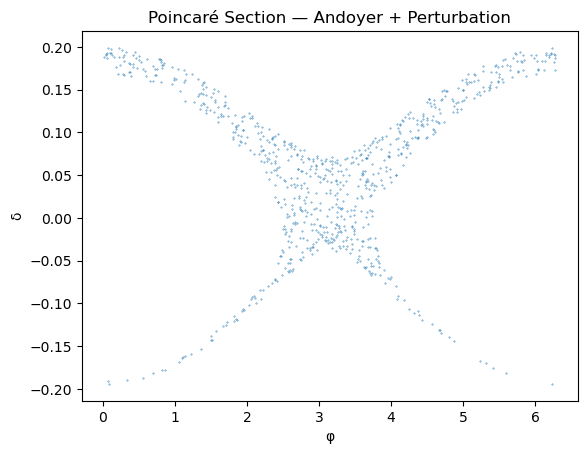

In [30]:
# Sample at t = n * 2pi/nu
T = 2 * np.pi / nu
times = np.arange(0, 1e5, T)
phi_section = sol.sol(times)[0] % (2*np.pi)
delta_section = sol.sol(times)[1]

plt.scatter(phi_section, delta_section, s=0.1)
plt.xlabel('φ')
plt.ylabel('δ')
plt.title('Poincaré Section — Andoyer + Perturbation')

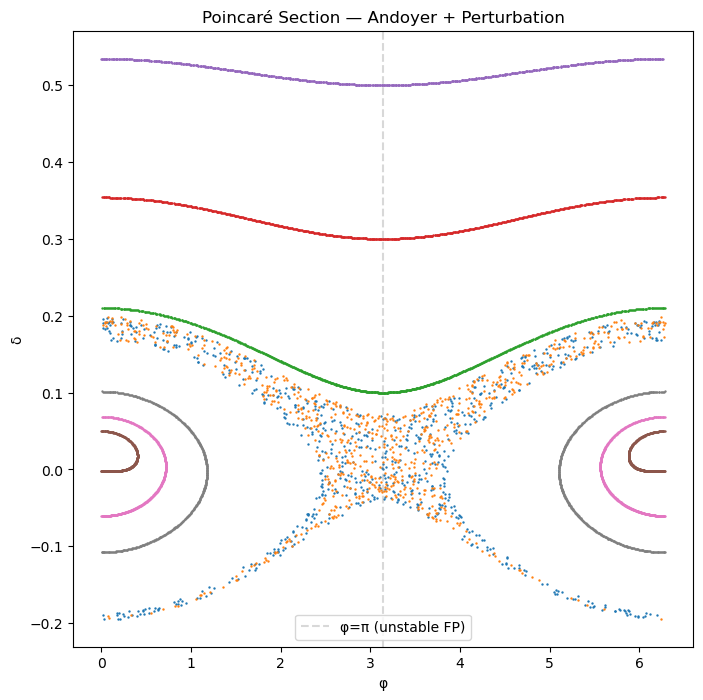

In [31]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

epsilon = 0.01
eta = 0.001
nu = 0.05
T = 2 * np.pi / nu
times = np.arange(0, 1e5, T)

fig, ax = plt.subplots(figsize=(8, 8))

# Initial conditions spanning phase space
initial_conditions = [
    (np.pi, 0.001),  
    (np.pi, 0.01),    
    (np.pi, 0.1),    
    (np.pi, 0.3),     
    (np.pi, 0.5),     
    (0.0,  0.05),     
    (0.5,  0.05),     
    (1.0,  0.05),     
]

for phi0, delta0 in initial_conditions:
    sol = solve_ivp(andoyer, [0, 1e5], [phi0, delta0],
                    args=(epsilon, eta, nu),
                    method='DOP853',
                    rtol=1e-10, atol=1e-12,
                    dense_output=True)
    
    phi_section = sol.sol(times)[0] % (2 * np.pi)
    delta_section = sol.sol(times)[1]
    ax.scatter(phi_section, delta_section, s=0.5)

ax.set_xlabel('φ')
ax.set_ylabel('δ')
ax.set_title('Poincaré Section — Andoyer + Perturbation')
ax.axvline(np.pi, color='gray', linestyle='--', alpha=0.3, label='φ=π (unstable FP)')
plt.legend()
plt.show()

In [33]:
import rebound
import celmech
from celmech import Poincare, PoincareHamiltonian
import numpy as np

# Build simulation matching your rebound setup
sim = rebound.Simulation()
sim.add(m=1, hash="Sun")
sim.add(m=1e-10, a=5.6, e=0.06, inc=0, Omega=0, pomega=np.radians(13.983865), hash="Jupiter")
sim.add(m=1e-10, a=8.9, e=0.03, inc=0, Omega=0, pomega=np.radians(88.719425), hash="Saturn")
sim.move_to_com()

# Convert to Poincare variables
pvars = Poincare.from_Simulation(sim)
pham = PoincareHamiltonian(pvars)

# Add ONLY the leading 2:1 term (max_order=1 gives the dominant e^1 term)
pham.add_MMR_terms(2, 1, max_order=1, indexIn=1, indexOut=2)

# Inspect the Hamiltonian terms
pham.df

<IPython.core.display.Math object>

In [36]:
pvars = Poincare.from_Simulation(sim)
pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(2, 1, max_order=1, indexIn=1, indexOut=2)

# Print the symbolic Hamiltonian to see its structure
print(pham.H)

# Get the numerical values directly using celmech's built-in method
print(pham.state)        # current state vector
print(pham.H_params)     # parameter dictionary (masses, semi-major axes etc.)

# Evaluate Hamiltonian at current state
H_val = pham.calculate_H()
print(f"H value: {H_val}")

# To see individual term coefficients, iterate over terms
for i, term in enumerate(pham.H.as_ordered_terms()):
    print(f"Term {i}: {term}")

-C_{(2,-1,-1,0,0,0)}^{(0,0,0,0),(0,0)}(\alpha_{1,2})*G*m1*m2*(eta1*sin(lambda1 - 2*lambda2)/sqrt(\Lambda_{1,0}) + kappa1*cos(lambda1 - 2*lambda2)/sqrt(\Lambda_{1,0}))/a_{2,0} - C_{(2,-1,0,-1,0,0)}^{(0,0,0,0),(0,0)}(\alpha_{1,2})*G*m1*m2*(eta2*sin(lambda1 - 2*lambda2)/sqrt(\Lambda_{2,0}) + kappa2*cos(lambda1 - 2*lambda2)/sqrt(\Lambda_{2,0}))/a_{2,0} - G**2*M2**2*mu2**3/(2*Lambda2**2) - G**2*M1**2*mu1**3/(2*Lambda1**2)
t=0.0, lambda1=0.2440644850925029, eta1=-2.231404530387272e-07, rho1=-0.0, lambda2=1.5484460786869763, eta2=-5.180947021491208e-07, rho2=-0.0, Lambda1=2.3664319130674464e-10, kappa1=8.960423722434943e-07, sigma1=0.0, Lambda2=2.983286778093859e-10, kappa2=1.1581473645694326e-08, sigma2=0.0
{G: 1.0, mu1: np.float64(9.999999999e-11), m1: np.float64(1e-10), M1: np.float64(1.0000000001), \Lambda_{1,0}: np.float64(2.3664319130674464e-10), a_{1,0}: np.float64(5.599999999744054), \alpha_{1,2}: np.float64(0.6292134830296695), mu2: np.float64(9.999999999e-11), m2: np.float64(1e-10),

In [ ]:
# The Andoyer Hamiltonian is written in normalized units
# epsilon = |f_res| * (m_jup / m_star) * n_out^2 * a_out^2
# where f_res is the Laplace coefficient combination

# Extract Jupiter's mass ratio and orbital frequency
m_jup_ratio = 1e-3   # Jupiter/Sun (use your actual value)
a_out = 8.9
n_out = a_out**(-1.5)  # mean motion in units where GM=1

# The resonant coefficient from celmech (read from pham.H output)
f_res = None  # <-- fill in from Step 2 output

epsilon = np.abs(f_res) * m_jup_ratio * n_out**2 * a_out**2
print(f"epsilon = {epsilon}")

In [37]:
import numpy as np

# Values read directly from H_params output
G = 1.0
m1 = 1e-10  # Jupiter (inner)
m2 = 1e-10  # Saturn test particle (outer)
a2_0 = 8.900000001239636
Lambda1_0 = 2.3664319130674464e-10
Lambda2_0 = 2.983286778093859e-10

# Laplace coefficients from H_params
C_inner = -1.18659211983332   # C_{(2,-1,-1,0,0,0)} - couples to inner planet eccentricity
C_outer =  0.424072473184706  # C_{(2,-1,0,-1,0,0)} - couples to outer planet eccentricity

# Current state values
kappa1 = 8.960423722434943e-07
eta1   = -2.231404530387272e-07
kappa2 = 1.1581473645694326e-08
eta2   = -5.180947021491208e-07

# Eccentricity vectors: e*cos(pomega) = kappa/sqrt(2*Lambda_0), same for eta/sin
# The resonant amplitude for each term
A_inner = G * m1 * m2 * np.abs(C_inner) / a2_0 * np.sqrt(kappa1**2 + eta1**2) / np.sqrt(Lambda1_0)
A_outer = G * m1 * m2 * np.abs(C_outer) / a2_0 * np.sqrt(kappa2**2 + eta2**2) / np.sqrt(Lambda2_0)

print(f"Inner planet resonant amplitude: {A_inner:.6e}")
print(f"Outer planet resonant amplitude: {A_outer:.6e}")

# Total epsilon is the combined resonant forcing amplitude
# Since Saturn is the test particle (m2=1e-10 ~ 0), 
# the dominant term is the one coupling to Jupiter's eccentricity (inner)
epsilon = A_inner + A_outer
print(f"\nepsilon = {epsilon:.6e}")

# Sanity check: epsilon should be << H_kepler
H_kepler = -G**2 * 1.0**2 * m2**3 / (2 * Lambda2_0**2)
print(f"H_kepler (outer) = {H_kepler:.6e}")
print(f"epsilon / H_kepler = {epsilon/np.abs(H_kepler):.6e}  (should be << 1)")

Inner planet resonant amplitude: 8.003103e-23
Outer planet resonant amplitude: 1.429619e-23

epsilon = 9.432722e-23
H_kepler (outer) = -5.617978e-12
epsilon / H_kepler = 1.679024e-11  (should be << 1)
